Loading models...
Test set: 11100 images, 37 classes

Testing: Clean
  RF  acc=100.0%  f1=100.0%  loss=0.0073  time=27.0ms
  MN  acc=100.0%  f1=100.0%  loss=0.0000  time=60.7ms

Testing: Noise
  RF  acc=54.0%  f1=52.0%  loss=2.0619  time=26.1ms
  MN  acc=10.0%  f1=7.0%  loss=7.1903  time=54.4ms

Testing: Blur
  RF  acc=99.9%  f1=99.9%  loss=0.0666  time=26.7ms
  MN  acc=7.6%  f1=3.7%  loss=5.7498  time=57.9ms

Testing: Dark
  RF  acc=2.7%  f1=0.2%  loss=23.1196  time=26.6ms
  MN  acc=100.0%  f1=100.0%  loss=0.0009  time=57.7ms

Testing: Bright
  RF  acc=2.7%  f1=0.3%  loss=26.1995  time=26.7ms
  MN  acc=99.8%  f1=99.8%  loss=0.0072  time=57.8ms

Testing: Rotation
  RF  acc=12.2%  f1=6.2%  loss=9.4316  time=26.6ms
  MN  acc=88.3%  f1=87.1%  loss=0.5278  time=57.9ms

Testing: Occlusion
  RF  acc=92.7%  f1=92.7%  loss=0.4019  time=26.6ms
  MN  acc=77.5%  f1=77.8%  loss=1.0931  time=58.3ms


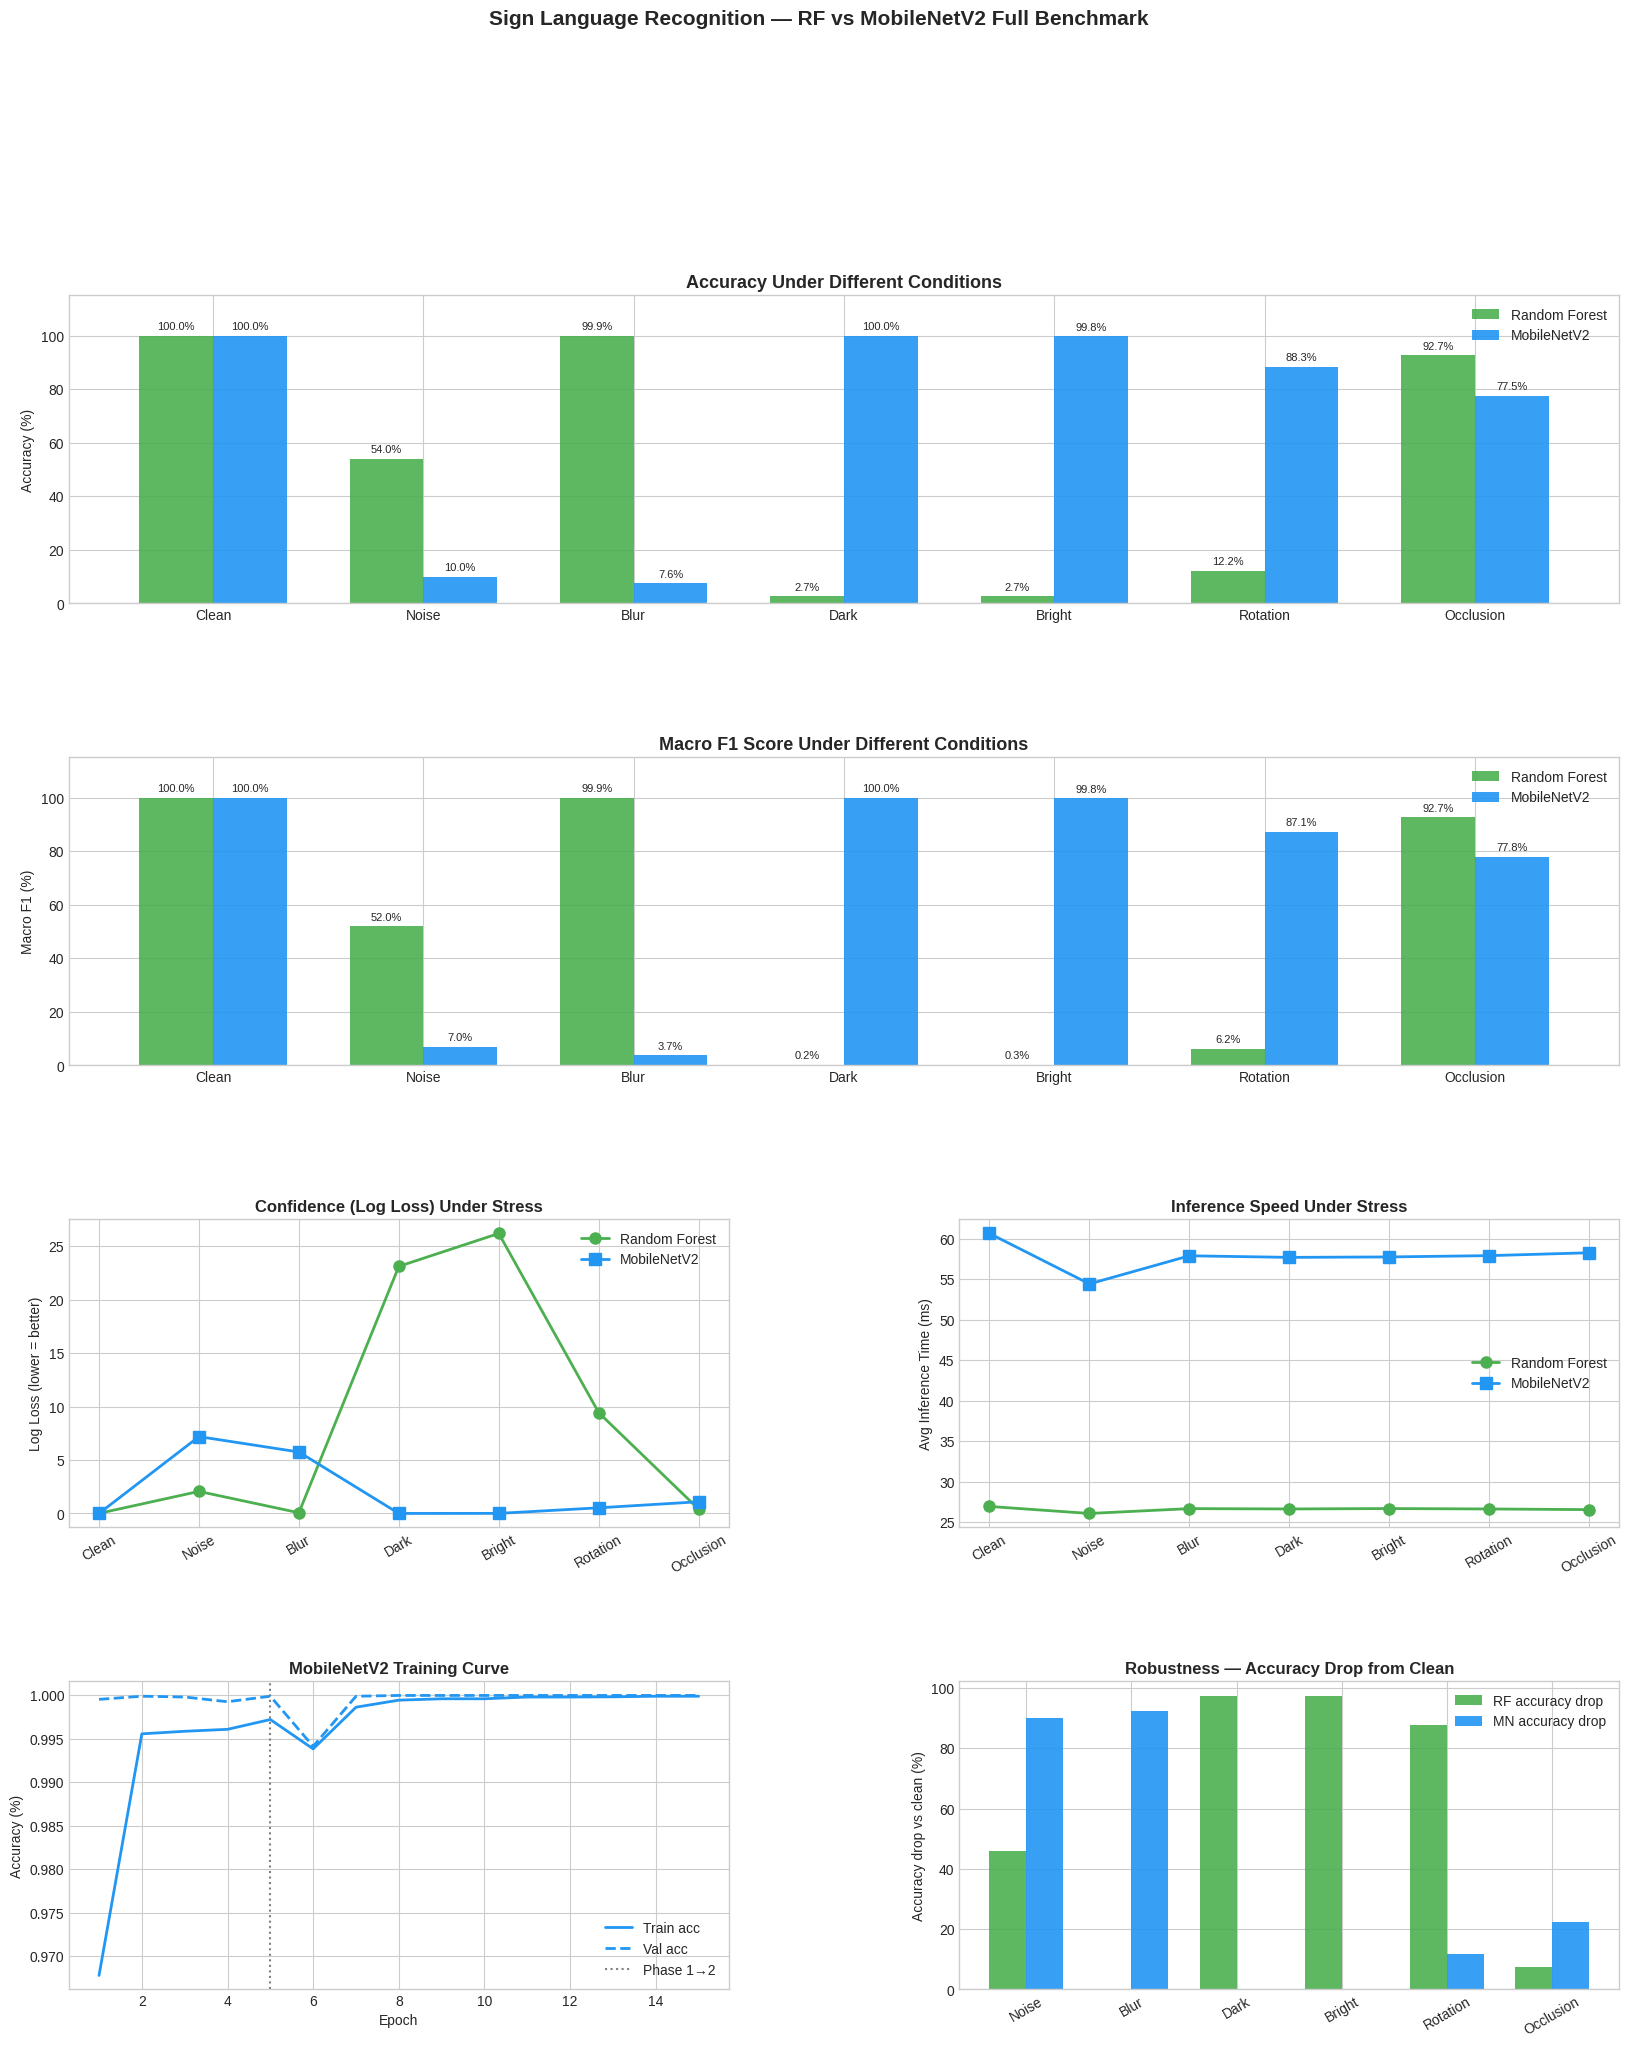


Saved → benchmark_results.png


In [3]:
import os, time, pickle, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import accuracy_score, f1_score, log_loss
import tensorflow as tf

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

print("Loading models...")
rf_model      = pickle.load(open("model_rf.pkl","rb"))["model"]
mn_model      = tf.keras.models.load_model("model_mobilenet.keras")
class_indices = pickle.load(open("class_indices.pkl","rb"))
idx_to_class  = {v:k for k,v in class_indices.items()}
mn_history    = pickle.load(open("mobilenet_history.pkl","rb"))
GRAY_DIR      = "data/grayscale"

# ── Build test set ────────────────────────────────────
paths, true_labels = [], []
for cls in sorted(os.listdir(GRAY_DIR)):
    folder = os.path.join(GRAY_DIR, cls)
    if not os.path.isdir(folder): continue
    imgs = sorted(os.listdir(folder))
    for f in imgs[int(len(imgs)*0.8):]:
        paths.append(os.path.join(folder, f))
        true_labels.append(cls)

print(f"Test set: {len(paths)} images, {len(set(true_labels))} classes")

# ── Augmentation functions ────────────────────────────
def add_noise(img, level=25):
    noise = np.random.normal(0, level, img.shape).astype(np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

def add_blur(img, ksize=5):
    return cv2.GaussianBlur(img, (ksize, ksize), 0)

def change_brightness(img, factor=0.5):
    return np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

def add_rotation(img, angle=15):
    h, w = img.shape[:2]
    M    = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))

def add_occlusion(img, size=15):
    out = img.copy()
    h, w = out.shape[:2]
    x, y = np.random.randint(0, w-size), np.random.randint(0, h-size)
    out[y:y+size, x:x+size] = 0
    return out

augmentations = {
    "Clean"       : lambda img: img,
    "Noise"       : lambda img: add_noise(img, 25),
    "Blur"        : lambda img: add_blur(img, 7),
    "Dark"        : lambda img: change_brightness(img, 0.4),
    "Bright"      : lambda img: change_brightness(img, 1.8),
    "Rotation"    : lambda img: add_rotation(img, 20),
    "Occlusion"   : lambda img: add_occlusion(img, 20),
}

# ── Evaluate both models under each augmentation ──────
def predict_rf(img_gray):
    resized  = cv2.resize(img_gray, (50, 50))
    features = resized.flatten() / 255.0
    pred     = rf_model.predict([features])[0]
    prob     = rf_model.predict_proba([features])[0]
    return pred, prob

def predict_mn(img_gray):
    rgb  = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    inp  = np.expand_dims(cv2.resize(rgb, (224,224)) / 255.0, 0)
    prob = mn_model.predict(inp, verbose=0)[0]
    return idx_to_class[np.argmax(prob)], prob

results = {}

for aug_name, aug_fn in augmentations.items():
    print(f"\nTesting: {aug_name}")
    rf_preds, rf_probs = [], []
    mn_preds, mn_probs = [], []
    rf_times, mn_times = [], []

    for path, label in zip(paths, true_labels):
        img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        aug_img  = aug_fn(img_gray)

        t0 = time.perf_counter()
        rp, rprob = predict_rf(aug_img)
        rf_times.append((time.perf_counter()-t0)*1000)
        rf_preds.append(rp)
        rf_probs.append(rprob)

        t0 = time.perf_counter()
        mp, mprob = predict_mn(aug_img)
        mn_times.append((time.perf_counter()-t0)*1000)
        mn_preds.append(mp)
        mn_probs.append(mprob)

    results[aug_name] = {
        "rf_acc"  : accuracy_score(true_labels, rf_preds)*100,
        "mn_acc"  : accuracy_score(true_labels, mn_preds)*100,
        "rf_f1"   : f1_score(true_labels, rf_preds, average="macro")*100,
        "mn_f1"   : f1_score(true_labels, mn_preds, average="macro")*100,
        "rf_loss" : log_loss(true_labels, rf_probs),
        "mn_loss" : log_loss(true_labels, mn_probs),
        "rf_time" : np.mean(rf_times),
        "mn_time" : np.mean(mn_times),
    }
    r = results[aug_name]
    print(f"  RF  acc={r['rf_acc']:.1f}%  f1={r['rf_f1']:.1f}%  loss={r['rf_loss']:.4f}  time={r['rf_time']:.1f}ms")
    print(f"  MN  acc={r['mn_acc']:.1f}%  f1={r['mn_f1']:.1f}%  loss={r['mn_loss']:.4f}  time={r['mn_time']:.1f}ms")

# ══════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════
RF_C = "#4CAF50"
MN_C = "#2196F3"
augs  = list(results.keys())
plt.style.use("seaborn-v0_8-whitegrid")
fig   = plt.figure(figsize=(20, 22))
gs    = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

# 1 — Accuracy under augmentation
ax1 = fig.add_subplot(gs[0, :])
x   = np.arange(len(augs))
w   = 0.35
b1  = ax1.bar(x-w/2, [results[a]["rf_acc"] for a in augs], w, label="Random Forest", color=RF_C, alpha=0.9)
b2  = ax1.bar(x+w/2, [results[a]["mn_acc"] for a in augs], w, label="MobileNetV2",   color=MN_C, alpha=0.9)
ax1.bar_label(b1, fmt="%.1f%%", padding=3, fontsize=8)
ax1.bar_label(b2, fmt="%.1f%%", padding=3, fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(augs)
ax1.set_ylabel("Accuracy (%)"); ax1.set_ylim(0, 115)
ax1.set_title("Accuracy Under Different Conditions", fontweight="bold", fontsize=13)
ax1.legend()

# 2 — F1 Score under augmentation
ax2 = fig.add_subplot(gs[1, :])
b3  = ax2.bar(x-w/2, [results[a]["rf_f1"] for a in augs], w, label="Random Forest", color=RF_C, alpha=0.9)
b4  = ax2.bar(x+w/2, [results[a]["mn_f1"] for a in augs], w, label="MobileNetV2",   color=MN_C, alpha=0.9)
ax2.bar_label(b3, fmt="%.1f%%", padding=3, fontsize=8)
ax2.bar_label(b4, fmt="%.1f%%", padding=3, fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(augs)
ax2.set_ylabel("Macro F1 (%)"); ax2.set_ylim(0, 115)
ax2.set_title("Macro F1 Score Under Different Conditions", fontweight="bold", fontsize=13)
ax2.legend()

# 3 — Log Loss under augmentation
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(augs, [results[a]["rf_loss"] for a in augs], "o-", color=RF_C, linewidth=2, markersize=8, label="Random Forest")
ax3.plot(augs, [results[a]["mn_loss"] for a in augs], "s-", color=MN_C, linewidth=2, markersize=8, label="MobileNetV2")
ax3.set_ylabel("Log Loss (lower = better)")
ax3.set_title("Confidence (Log Loss) Under Stress", fontweight="bold")
ax3.tick_params(axis="x", rotation=30)
ax3.legend()

# 4 — Inference speed under augmentation
ax4 = fig.add_subplot(gs[2, 1])
ax4.plot(augs, [results[a]["rf_time"] for a in augs], "o-", color=RF_C, linewidth=2, markersize=8, label="Random Forest")
ax4.plot(augs, [results[a]["mn_time"] for a in augs], "s-", color=MN_C, linewidth=2, markersize=8, label="MobileNetV2")
ax4.set_ylabel("Avg Inference Time (ms)")
ax4.set_title("Inference Speed Under Stress", fontweight="bold")
ax4.tick_params(axis="x", rotation=30)
ax4.legend()

# 5 — MobileNetV2 training curve
ax5 = fig.add_subplot(gs[3, 0])
epochs = range(1, len(mn_history["train_acc"])+1)
ax5.plot(epochs, mn_history["train_acc"], color=MN_C, linewidth=2, label="Train acc")
ax5.plot(epochs, mn_history["val_acc"],   color=MN_C, linewidth=2, linestyle="--", label="Val acc")
if "phase1_epochs" in mn_history:
    ax5.axvline(mn_history["phase1_epochs"], color="gray", linestyle=":", linewidth=1.5, label="Phase 1→2")
ax5.set_xlabel("Epoch"); ax5.set_ylabel("Accuracy (%)")
ax5.set_title("MobileNetV2 Training Curve", fontweight="bold")
ax5.legend()

# 6 — Robustness radar (clean vs worst case)
ax6 = fig.add_subplot(gs[3, 1])
aug_labels = [a for a in augs if a != "Clean"]
rf_drop = [results["Clean"]["rf_acc"] - results[a]["rf_acc"] for a in aug_labels]
mn_drop = [results["Clean"]["mn_acc"] - results[a]["mn_acc"] for a in aug_labels]
x2 = np.arange(len(aug_labels))
ax6.bar(x2-w/2, rf_drop, w, label="RF accuracy drop",  color=RF_C, alpha=0.9)
ax6.bar(x2+w/2, mn_drop, w, label="MN accuracy drop",  color=MN_C, alpha=0.9)
ax6.set_xticks(x2); ax6.set_xticklabels(aug_labels, rotation=30)
ax6.set_ylabel("Accuracy drop vs clean (%)")
ax6.set_title("Robustness — Accuracy Drop from Clean", fontweight="bold")
ax6.legend()

plt.suptitle("Sign Language Recognition — RF vs MobileNetV2 Full Benchmark",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → benchmark_results.png")